**🐍BioPython**

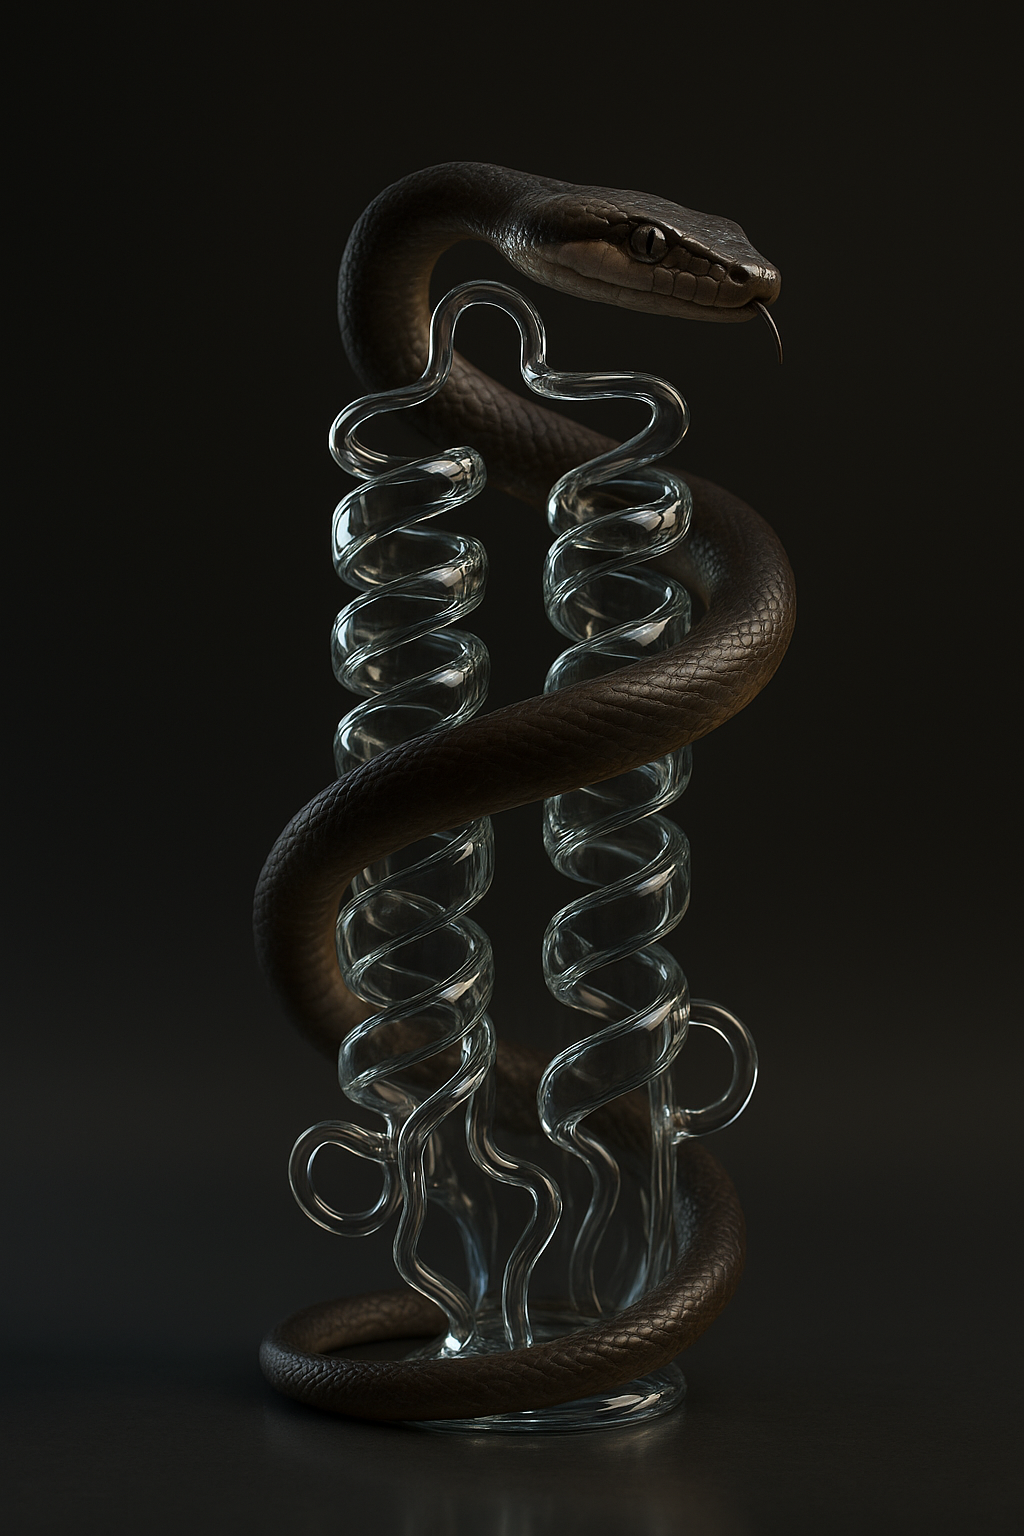

**Table of contents**<a id='toc0_'></a>    
- [Introduction](#toc1_)    
- [Getting Started](#toc2_)    
- [Reading and Analyzing 3D Structural Files](#toc3_)    
      - [Download and Read The Structure](#toc3_1_1_1_)    
      - [Structural Hierarchy in Biopython](#toc3_1_1_2_)    
    - [📝Exercise-1:](#toc3_1_2_)    
    - [📝Exercise-2: Exploring PDB ID 7VL8 with Biopython](#toc3_1_3_)    
- [Distograms (Bonus Section)](#toc4_)    
    - [🔹Interchain Distogram](#toc4_1_1_)    
    - [🔹Intrachain Distogram](#toc4_1_2_)    
- [🏠HomeWork](#toc5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Introduction](#toc0_)

Biopython is an open-source collection of tools written in Python that makes it easier to work with biological data. Whether you’re dealing with DNA and protein sequences, analyzing sequence alignments, or accessing online biological databases, Biopython provides ready-made modules that save you from reinventing the wheel.🛞

---

# <a id='toc2_'></a>[Getting Started](#toc0_)
Let's install and import biopython.

In [ ]:
#!pip install biopython

import Bio
print(Bio.__version__)


---

# <a id='toc3_'></a>[Reading and Analyzing 3D Structural Files](#toc0_)

Experimental structures in the Protein Data Bank (PDB) come from X-ray crystallography, NMR spectroscopy, or cryo-electron microscopy (Cryo-EM).

These structures are stored in two main file formats:


🗃️ **1. PDB (.pdb)**

 The original legacy format.

- Fixed-width columns → simple to read by eye.

- ❗️Limited flexibility → struggles with very large structures.

📁 **2. mmCIF (.cif)**

- The modern standard (now recommended by the PDB).

- More flexible and machine-readable.

- Can store much more complex information, better suited for large assemblies.

Let's work on the structure of the complex between **cAMP-dependent protein kinase catalytic subunit alpha(PKA‑α)** and **cAMP-dependent protein kinase inhibitor alpha(PKI‑α)**. First, we need to download the structure. The complex is available in both mmCIF and PDB formats on Protein Data Bank website.

#### <a id='toc3_1_1_1_'></a>[Download and Read The Structure](#toc0_)

* `PDBList()` is a Biopython class that knows how to talk to the Protein Data Bank (PDB) and download structures. By creating `pdbl = PDBList()`, we’re making a helper that we can use to fetch files.

* `retrieve_pdb_file(...)` is the code that actually downloads the file. It needs some arguments to know what to get and where to put it. `pdb_id` is the identifier of the structure in the Protein Data Bank (for example "4UJ1"). With `file_format="mmCif"` you can select your desired file format. `pdir="structures"` is the folder where the file should be saved. If the folder doesn’t exist, Biopython will usually create it.

* `MMCIFParser(QUIET=True)` creates a parser that can read mmCIF files. `QUIET=True` just hides warning messages.
* `get_structure(pdb_id, filename)` opens the downloaded file and turns it into a structured object that you can explore in Python.


In [ ]:
from Bio.PDB import PDBList
from Bio.PDB import MMCIFParser

#Let's download the structure first:

#------------pdb-----------------------------------
# pdb format:
# pdbl = PDBList()
# pdbl.retrieve_pdb_file("4UJ1", file_format="pdb", pdir="structures")

#---------------mmCif-------------------------------
# mmCif format:
# 4UJ1 is the pdb ID of your complex on Protein Data Bank.
# pdir specifies the folder where your file will be downloaded.
pdb_id = "4UJ1"
pdbl = PDBList()
filename = pdbl.retrieve_pdb_file(pdb_id, file_format="mmCif", pdir="structures")

cif_parser = MMCIFParser(QUIET=True)
structure = cif_parser.get_structure(pdb_id, filename)

#### <a id='toc3_1_1_2_'></a>[Structural Hierarchy in Biopython](#toc0_)
 
The `structure` variable works like a special container that holds the contents of an mmCIF file. Instead of giving you everything at once, this container lets you look inside step by step (or layer by layer like an onion 🧅). These layers follow a clear hierarchy — first the whole structure, then models, then chains, then residues, and finally atoms. In this way, you can “zoom in” layer by layer depending on the level of detail you need.

**Layers of the Hierarchy (structure → models → chains → residues → atoms)** 

1. **Structure**

* Top-level object returned by the parser.

* Represents the whole PDB/mmCIF entry (can contain multiple models).


2. **Model**


* X-ray crystallography / Cryo-EM: usually gives one model → a single 3D structure.

* NMR spectroscopy: often gives multiple models → each model is one possible conformation, representing the flexibility of the molecule in solution.

`Access: structure[0] → the first model`

3. **Chain**

* Each model contains one or more chains (e.g., protein subunits, DNA strands).

`Access: structure[0]["A"] → chain A of model 0`

4. **Residue**

* Each chain contains residues (amino acids, nucleotides, ligands).

* Each residue has an ID: (hetero flag, sequence number, insertion code)

Example: (" ", 100, " ") → residue 100, standard amino acid.

`Access: structure[0]["A"][100] → residue number 100 in chain A`

5. **Atom**

* Each residue contains atoms.

* Atoms store name, element, and 3D coordinates.

`Access: structure[0]["A"][100]["CA"] → alpha carbon atom of residue 100 in chain A`

**Let's see this in practice!**

In [ ]:
structure

In [ ]:
for model in structure:
    # Remember model means structural ensembles.
    print("Model Number", model.id)


In [ ]:
for model in structure:
    for chain in model:
        print("Chain ID ", chain.id)


So far, we’ve seen that the structure contains **a single model** and is made up of **two chains**. 

We can also select and print the residues for each chain, as shown below. The attribute `.resname` gives the three-letter amino acid code. To convert this into the corresponding one-letter code, we can use Biopython’s `protein_letters_3to1` dictionary. When converting three-letter residue names to one-letter amino acid codes, make sure to exclude non-amino acid molecules (e.g., water and ions). The protein_letters_3to1 dictionary only recognizes standard amino acids, and will return **None** for anything else.

Here we want to select and print the first 4 residues for chain B. 

In [ ]:
from Bio.Data.PDBData import protein_letters_3to1
for model in structure:
    for chain in model:
        for i, residue in enumerate(chain):

            # we want to only see the first 4 residues on chain B.
            if i >= 4:
                    break
            if chain.id =="B":

                # get_parent() reverses the hierarchy.
                print(f"Residue three-letter name: {residue.resname},"
                      f"Residue one-letter name: {protein_letters_3to1.get(residue.resname)},"
                      f"Residue ID: {residue.id},"
                      f"On chain: {residue.get_parent().id},"
                      f"List of Atoms: {residue.child_list}")
                



### <a id='toc3_1_2_'></a>[📝Exercise-1:](#toc0_)

Collect all residue names from chain A and build a string representing the amino acid sequence of the protein.

In [ ]:
seq = []
for res in structure[0]["A"]:
        letter = protein_letters_3to1.get(res.resname)
        # we add this if section to get rid of None values.
        if letter:
            seq.append(letter)


sequence = "".join(seq)
print(sequence)


**(An easier syntax):** You can also access chains and residues directly, without writing explicit loops, as shown in the example below.

In [ ]:
# we are looping through all of the residues in model 0 and chain B.
for i, res in enumerate(structure[0]["B"]):
    if i>=2:
        break
    # CA here is carbon alpha (Cα).
    print(f"The Carbon alpha coordinate in residue {res.resname} is {res['CA'].get_coord()}")
    

### <a id='toc3_1_3_'></a>[📝Exercise-2: Exploring PDB ID 7VL8 with Biopython](#toc0_)

[7VL8](https://www.rcsb.org/structure/7VL8) is a Cryo-EM structure of the Apo CCR1-Gi complex. 

**1. Load and Inspect the Structure**

Task: Download PDB entry 7VL8 using Biopython’s `PDBList` and parse it with `PDBParser`.

Questions:

* How many models are in this structure?

* What are the names of the chains?

In [ ]:
from Bio.PDB import PDBList
from Bio.PDB import MMCIFParser

pdbid = "7VL8"
pdblist = PDBList()
file = pdblist.retrieve_pdb_file(pdbid, file_format="mmCif", pdir= "structures")
cif_reader = MMCIFParser(QUIET=True)
struct = cif_reader.get_structure(pdbid, file)

models = list(struct)
print(f"Number of Models: {len(models)}")

chains = list(struct[0])
print(f"Chain names: {[chain.id for chain in chains]}")

**2. Chain Composition**

Task: Iterate over the chains and count the number of residues in each chain.

Questions:

* Which chain is the CCR1 receptor?

* Check the Protein Data Bank (PDB) website to identify which chains correspond to the Gi protein.

In [ ]:
for chain in struct[0]:
    residues = [res for res in chain if res.id[0] == " "]  # skip hetero atoms
    print(f"Chain {chain.id}: {len(residues)} residues")

# Gi protein = Chain A (subunit alpha)+ chain B (sununit beta) + chain C (subunit gamma)

**3. Atoms and Coordinates**

Task: For chain A, print the CA (alpha carbon) coordinates of the first 5 residues.

🔥Bonus: Compute the distance between the CA atoms of residue 50 and residue 150 of chain A.

**🤫Hint**: The atom’s 3D coordinates are stored in the .coord attribute (a NumPy array). Use Numpy for the distance calculation.

In [ ]:
from Bio.PDB import NeighborSearch
import numpy as np

chainA = structure[0]["A"]

# First 5 CA coordinates
for i, residue in enumerate(chainA):
    if "CA" in residue:
        print(residue.id, residue["CA"].coord)
    if i >= 4:
        break

# Distance between CA atoms of residue 50 and 150
res50 = chainA[(" ", 50, " ")]["CA"].coord
res150 = chainA[(" ", 150, " ")]["CA"].coord
distance = np.linalg.norm(res50 - res150)

print("Distance between residue 50 CA and 150 CA:", distance, "Å")


---

# <a id='toc4_'></a>[Distograms (Bonus Section)](#toc0_)

To better understand the distances within our protein, we can visualize them using a distogram. A distogram is a 2D matrix that represents the pairwise distances between atoms (or residues) in a biomolecule such as a protein. By plotting it as a heatmap, we obtain an intuitive map of how close or far different parts of the structure are from each other.

We will use heatmaps to visualize the distances. A heatmap is a graphical tool that represents 3D data: the two axes correspond to the first two dimensions, while the color encodes the third dimension (the values). Here the two axis (x and y) will be the position of the amino acids on the chains, and the color of the plot shows the distances.

You can plot heatmaps using `plt.imshow(...)`, but you need to first create a matrix as an input to this function from the distances in between the residues and the index of the matrix will represent the position of your residue on the chain. `plt.imshow(...)` takes other arguments like:

* `dist_matrix` → the 2D array(matrix) you want to display.

* `cmap="viridis"` → sets the colormap (here, viridis gives a smooth blue→green→yellow scale, you can change it though).

* `aspect="auto"` → automatically adjusts the aspect ratio so the image fills the axes.

* `origin="lower"` → puts the [0,0] element of the matrix at the bottom-left instead of the top-left.

### <a id='toc4_1_1_'></a>[🔹Interchain Distogram](#toc0_)

Let's plot the distances between the chains A and B.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# We only have a single model here
model = structure[0]

chainA = model["A"]  # Kinase
chainB = model["B"]  # Inhibitor

# Collect residue IDs for residues that have carbon alpha
resA_ids = [res.id[1] for res in chainA if "CA" in res]
resB_ids = [res.id[1] for res in chainB if "CA" in res]

# first we create a matrix of zeros.
dist_matrix = np.zeros((len(resA_ids), len(resB_ids)))


for i, resA in enumerate(chainA):
    if "CA" not in resA:
        continue
    for j, resB in enumerate(chainB):
        if "CA" not in resB:
            continue
        dist_matrix[i, j] = np.linalg.norm(resA["CA"].coord - resB["CA"].coord) # you can write this as well: resA["CA"] - resB["CA"], why?

# Here we can change the size of the figure
plt.figure(figsize=(10,6))
im = plt.imshow(dist_matrix, cmap="viridis", aspect="auto", origin="lower")

# we want the x coordinate ticks have int numbers representing the index of our amino acids.
plt.xticks(ticks=np.arange(len(resB_ids)), labels=resB_ids, rotation=90)


# Add colorbar with fixed intervals
cbar = plt.colorbar(im, label="Cα–Cα Distance (Å)")


plt.xlabel("Residues in Chain B")
plt.ylabel("Residues in Chain A")
plt.title("Interchain Distance Map (Distogram)")
plt.tight_layout()
plt.show()


### <a id='toc4_1_2_'></a>[🔹Intrachain Distogram](#toc0_)
we want to see the distances inside chain B which is our inhibitor.

In [ ]:
chainB = model["B"]  # Inhibitor

# This time we are only working with chain B which is the inhibitor.
resB_ids = [res.id[1] for res in chainB if "CA" in res]
n = len(resB_ids)
dist_matrix = np.zeros((n, n))

for i, resB1 in enumerate(chainB):
    if "CA" not in resB1:
        continue
    for j, resB2 in enumerate(chainB):
        if "CA" not in resB2:
            continue
        # only Cα–Cα distance
        dist_matrix[i, j] = np.linalg.norm(resB1["CA"].coord - resB2["CA"].coord)


plt.figure(figsize=(10,6))
im = plt.imshow(dist_matrix, cmap="viridis", aspect="auto", origin="lower")
# here we make sure both axis can clearly represent residue numbers.
plt.xticks(ticks=np.arange(len(resB_ids)), labels=resB_ids, rotation=90)
plt.yticks(ticks=np.arange(len(resB_ids)), labels=resB_ids)

cbar = plt.colorbar(im, label="Cα–Cα Distance (Å)")
plt.xlabel("Residues in Chain B")
plt.ylabel("Residues in Chain B")
plt.title("Intra-chain Distance Map (Distogram)")
plt.tight_layout()
plt.show()


# <a id='toc5_'></a>[🏠HomeWork](#toc0_)

Create the same plots but this time for `pdb_id=2H3T`.

**Challenge(optional)👹:** plot the heatmaps with seaborn this time!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Download and parse 
PDB_ID = "2H3T"
PDBLIST = PDBList()
file_PDB = PDBLIST.retrieve_pdb_file(PDB_ID, file_format="mmCif", pdir="structures")

parse_cif = MMCIFParser(QUIET=True)
structure = parse_cif.get_structure(PDB_ID, file_PDB)
model = structure[0]

#### Collect Cα coordinates per chain 
chain_residues = {}
for chain in model:
    residues = [res for res in chain if "CA" in res]  # only standard residues
    if residues:
        ids = [res.id[1] for res in residues]
        coords = np.array([res["CA"].coord for res in residues])
        chain_residues[chain.id] = {"ids": ids, "coords": coords}

print("Chains found:", list(chain_residues.keys()))

#### Helper function: pairwise distances  
def pairwise_distances(coords1, coords2=None):
    if coords2 is None:
        coords2 = coords1
    diff = coords1[:, None, :] - coords2[None, :, :]
    return np.sqrt(np.sum(diff**2, axis=-1))

#### Intrachain
for chain_id, data in chain_residues.items():
    dist_mat = pairwise_distances(data["coords"])
    plt.figure(figsize=(6, 5))
    sns.heatmap(dist_mat, cmap="magma_r", cbar_kws={"label": "Cα–Cα Distance (Å)"})
    plt.title(f"Intrachain Distance Heatmap (Chain {chain_id})")
    plt.xlabel("Residues")
    plt.ylabel("Residues")
    plt.show()

#### Interchain (pairwise)
chain_ids = list(chain_residues.keys())
for i in range(len(chain_ids)):
    for j in range(i + 1, len(chain_ids)):
        ci, cj = chain_ids[i], chain_ids[j]
        coords_i, coords_j = chain_residues[ci]["coords"], chain_residues[cj]["coords"]

        dist_mat = pairwise_distances(coords_i, coords_j)
        plt.figure(figsize=(6, 5))
        sns.heatmap(dist_mat, cmap="viridis", cbar_kws={"label": "Cα–Cα Distance (Å)"})
        plt.title(f"Interchain Distance Heatmap ({ci} vs {cj})")
        plt.xlabel(f"Chain {cj} residues")
        plt.ylabel(f"Chain {ci} residues")
        plt.show()